In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
#from sklearn.preprocessing import StandardScaler
import numpy as np

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.cluster import HDBSCAN
import astropy.units as u
# from zero_point import zpt
from tqdm import tqdm
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import hdbscan

In [35]:
import os
import matplotlib.pyplot as plt

OUTDIR = "figuras"
os.makedirs(OUTDIR, exist_ok=True)

def save_current_fig(filename, dpi=300):
    """Guarda la figura actual con el nombre exacto."""
    path = os.path.join(OUTDIR, filename)
    plt.gcf().savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved:", path)

Análisis usando HDBSCAN con datos M41_query_result_full

In [2]:
df = pd.read_csv('M41_query_result_full.csv') # full gaia sample for one cluster
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28196 entries, 0 to 28195
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   random_index         28196 non-null  int64  
 1   source_id            28196 non-null  int64  
 2   ra                   28196 non-null  float64
 3   dec                  28196 non-null  float64
 4   parallax             28196 non-null  float64
 5   parallax_over_error  28196 non-null  float64
 6   pmdec                28196 non-null  float64
 7   pmdec_error          28196 non-null  float64
 8   pmra                 28196 non-null  float64
 9   pmra_error           28196 non-null  float64
 10  ruwe                 28196 non-null  float64
 11  phot_g_mean_mag      28149 non-null  float64
 12  phot_bp_mean_mag     27593 non-null  float64
 13  phot_rp_mean_mag     27629 non-null  float64
 14  bp_rp                27590 non-null  float64
dtypes: float64(13), int64(2)
memory usage: 3.2 MB


Saved: figuras\fig_03_00_18881921.png


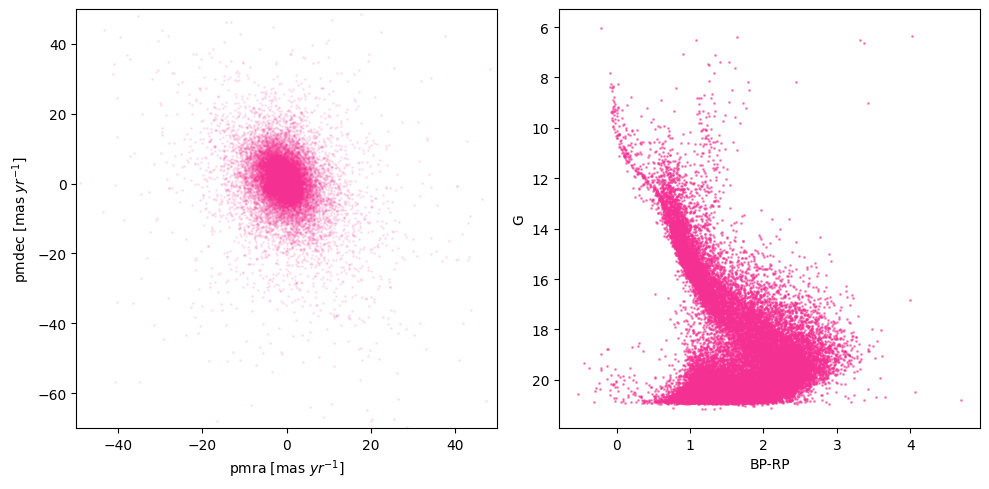

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].scatter(df['pmra'], df['pmdec'], s=1, alpha=0.1, color="#F53093")
ax[0].set_xlabel("pmra [mas $yr^{-1}$]")
ax[0].set_ylabel("pmdec [mas $yr^{-1}$]")
ax[0].set_xlim(-50, 50)
ax[0].set_ylim(-70, 50)

ax[1].scatter(df['phot_bp_mean_mag'] - df['phot_rp_mean_mag'], df['phot_g_mean_mag'], s=1, alpha=0.5, color="#F53093")
ax[1].set_xlabel("BP-RP")
ax[1].set_ylabel("G")
ax[1].invert_yaxis()
fig.tight_layout()
save_current_fig("fig_03_00_18881921.png")


In [4]:
clustering_on = ['pmra','pmdec','parallax']
import pandas as pd
data = df[clustering_on]
data = RobustScaler().fit_transform(data)

In [5]:
#hd = HDBSCAN(min_cluster_size=20, min_samples=5, metric='mahalanobis', metric_params={'V': np.cov(data, rowvar=False)}).fit(data)
hd = HDBSCAN(min_cluster_size=100, min_samples=10, metric='euclidean').fit(data)

In [6]:
labels = hd.labels_ 
df['label_hb'] = labels
for i in list(set(labels)):
    print('{} {}'.format(i,len(df[(df['label_hb'] == i)])))

0 8994
1 1110
-1 18092


Saved: figuras\fig_07_00_a6aaf2a4.png


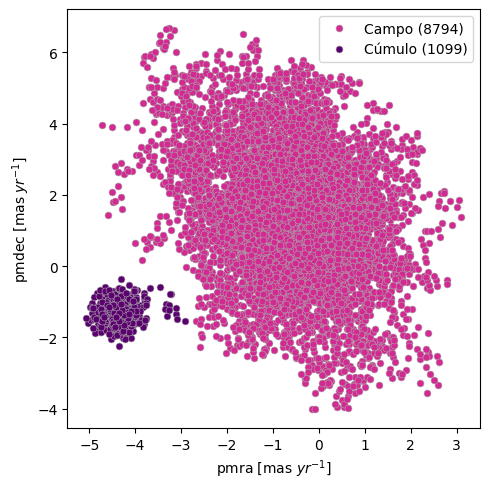

In [50]:
unique_labels = sorted(set(labels))
pink_colors = [plt.cm.RdPu(each) for each in np.linspace(0.35, 0.95, len(unique_labels))]

nombres = {0: "Campo", 1: "Cúmulo"}   # cambia 0 y 1 si están al revés

plt.figure(figsize=(5,5))
for i, j in zip(unique_labels, pink_colors):
    if i != -1:
        condition = (df['label_hb'] == i)
        nombre = nombres.get(i, f"Cluster {i}")
        plt.plot(
            df['pmra'][condition],
            df['pmdec'][condition],
            marker='o',
            linestyle='None',
            markersize=5,
            alpha=1,
            markerfacecolor=tuple(j),
            markeredgecolor='darkgray',
            markeredgewidth=0.4,
            label=f"{nombre} ({len(df[condition])})"
        )

plt.xlabel("pmra [mas $yr^{-1}$]")
plt.ylabel("pmdec [mas $yr^{-1}$]")
plt.legend()
plt.tight_layout()
save_current_fig("fig_07_00_a6aaf2a4.png")
plt.show()


In [8]:
unique_labels

[np.int64(-1), np.int64(0), np.int64(1)]

Saved: figuras\fig_09_00_77b8317c.png


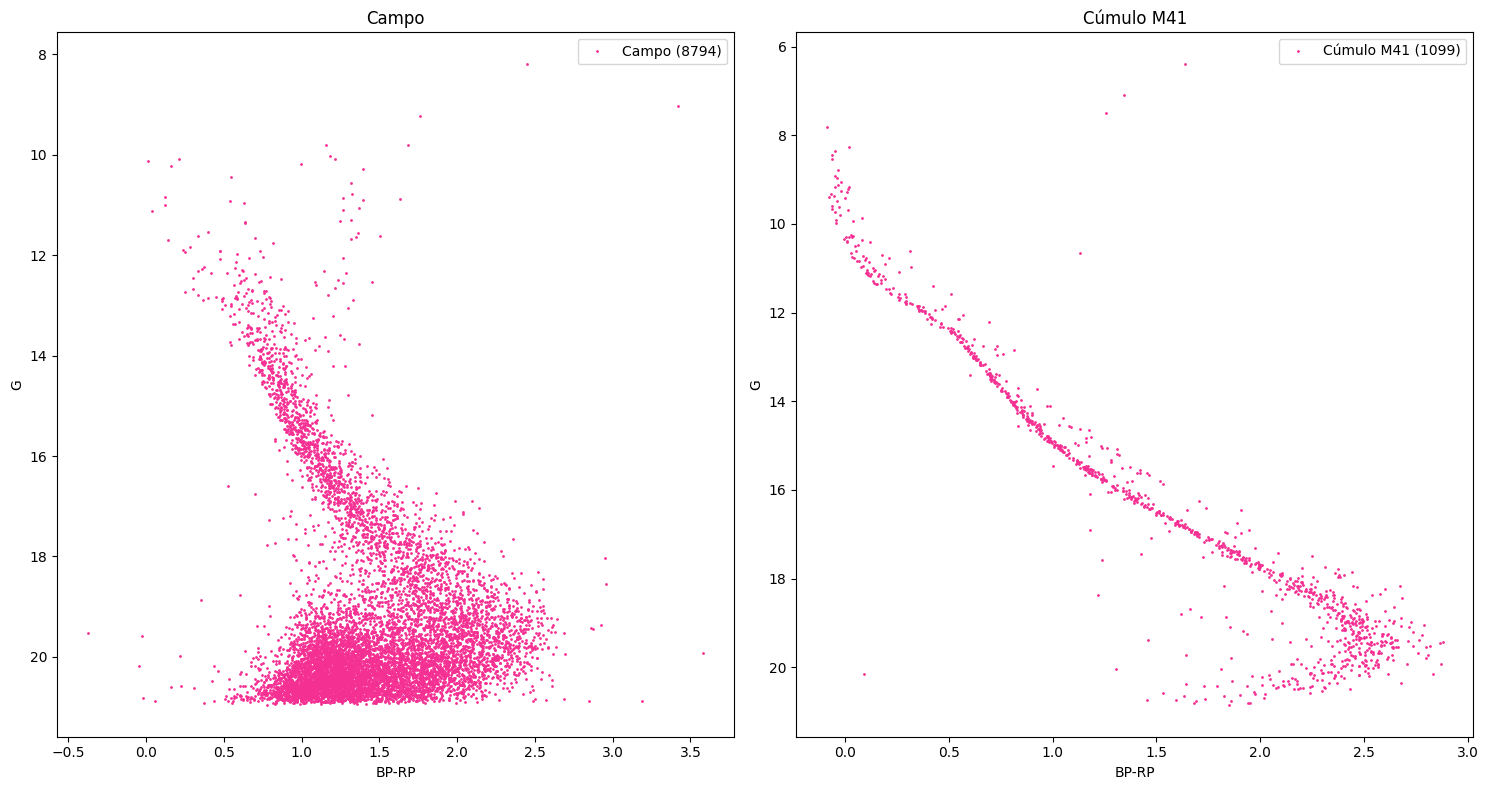

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

labels_to_plot = [0,1] 
nombres = ["Campo", "Cúmulo M41"]

for i, ax, nombre in zip(labels_to_plot, axes.flat, nombres):
    condition = (df['label_hb'] == i)
    ax.plot(
        df['phot_bp_mean_mag'][condition] - df['phot_rp_mean_mag'][condition],
        df['phot_g_mean_mag'][condition],
        marker='o',
        linestyle='None',
        markersize=1,
        color="#F53093",
        label=f"{nombre} ({condition.sum()})"
    )
    ax.set_xlabel("BP-RP")
    ax.set_ylabel("G")
    ax.invert_yaxis()
    ax.legend()
    ax.set_title(nombre)

fig.tight_layout()
save_current_fig("fig_09_00_77b8317c.png")
plt.show()


In [10]:
from sklearn.metrics import silhouette_samples, silhouette_score


In [11]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import matplotlib.pyplot as plt

# SOLO datos asignados por HDBSCAN (sin ruido)
condition = df['label_hb'] != -1

# DataFrame filtrado
df_hdb = df[condition].copy()

# Matriz usada en HDBSCAN, filtrada igual
data_hdb = data[condition]

# Labels filtrados
labels_hdb = df_hdb['label_hb'].values

# Silueta solo sobre los datos retenidos por HDBSCAN
if len(np.unique(labels_hdb)) < 2:
    print("No hay suficientes clusters para calcular silueta.")
else:
    sil_avg = silhouette_score(data_hdb, labels_hdb)
    sil_vals = silhouette_samples(data_hdb, labels_hdb)

    df_hdb['silhouette'] = sil_vals

    print(f"Silhouette promedio: {sil_avg:.4f}")

Silhouette promedio: 0.5106


Saved: figuras\fig_12_00_3e2fd2e1.png


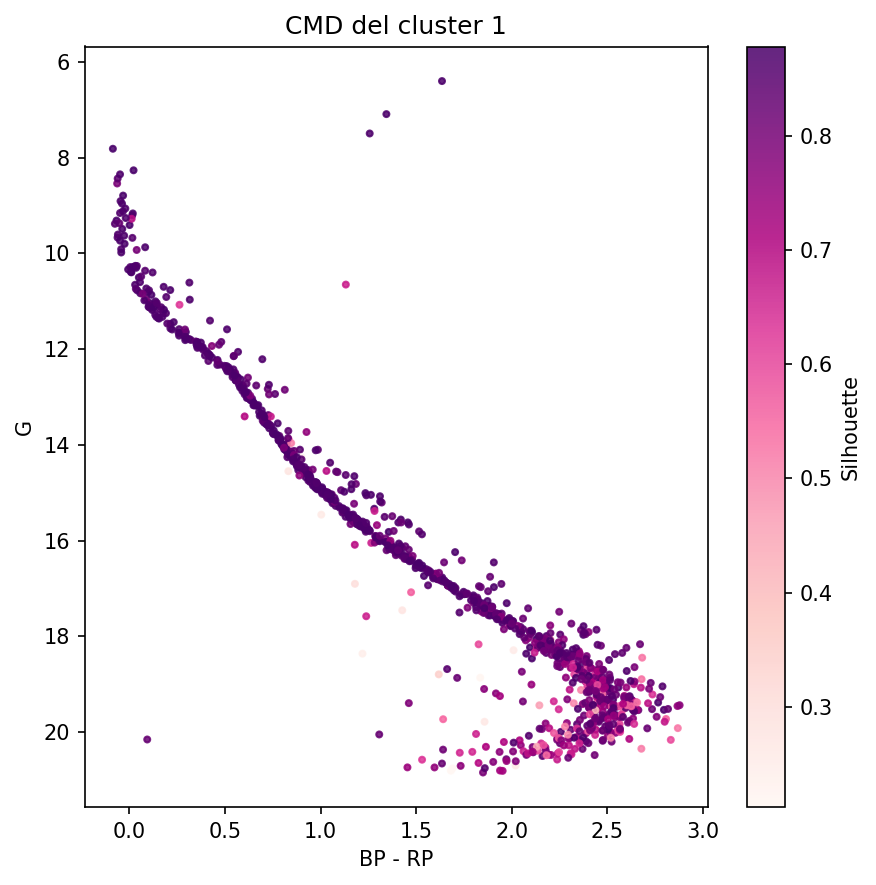

In [52]:
cond = df_hdb['label_hb'] == 1

plt.figure(figsize=(6,6), dpi=150)
sc = plt.scatter(
    df_hdb.loc[cond, 'phot_bp_mean_mag'] - df_hdb.loc[cond, 'phot_rp_mean_mag'],
    df_hdb.loc[cond, 'phot_g_mean_mag'],
    c=df_hdb.loc[cond, 'silhouette'],
    cmap='RdPu',
    s=8,
    alpha=0.85
)

plt.gca().invert_yaxis()
plt.xlabel("BP - RP")
plt.ylabel("G")
plt.title("CMD del cluster 1")
plt.colorbar(sc, label="Silhouette")
plt.tight_layout()
save_current_fig("fig_12_00_3e2fd2e1.png")
plt.show()


Análisis del set de datos con el método anatílico

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

In [14]:
pd.set_option("display.max_columns", 300)

#df = pd.read_csv('M41_query_result_full.csv')
#print(df.columns.tolist())
df.head()

,random_index,source_id,ra,dec,parallax,parallax_over_error,pmdec,pmdec_error,pmra,pmra_error,ruwe,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,label_hb
0,1381651595,2926059827481255680,101.871514,-21.638468,0.708287,15.724628,-4.061186,0.041292,-0.045740,0.029029,1.055384,16.628632,17.203814,15.902876,1.300938,-1
1,226379506,2926062576260337408,101.791043,-21.639748,0.856612,6.924300,-2.894021,0.112050,1.558011,0.080318,0.975567,18.450891,19.332483,17.522280,1.810204,0
2,741620331,2926062610615673472,101.767416,-21.651002,2.363314,1.571006,11.480609,1.119343,9.070124,0.716237,1.118750,20.810562,21.877844,19.674230,2.203613,-1
3,1021135133,2926062919857705472,101.840912,-21.604856,1.955211,113.311530,-35.483904,0.015670,-11.917450,0.011108,1.002468,14.496161,14.930145,13.892927,1.037218,-1
4,340816657,2926061614178561024,101.706995,-21.683744,0.868512,2.326162,2.742589,0.346593,2.426535,0.208912,1.020591,19.892107,20.634743,18.969057,1.665686,-1


In [15]:
df_alt = df[["phot_bp_mean_mag","phot_rp_mean_mag","bp_rp"]].copy()
df_alt["diff"] = df_alt["phot_bp_mean_mag"] - df_alt["phot_rp_mean_mag"]
df_alt.head()

,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,diff
0,17.203814,15.902876,1.300938,1.300938
1,19.332483,17.522280,1.810204,1.810203
2,21.877844,19.674230,2.203613,2.203614
3,14.930145,13.892927,1.037218,1.037218
4,20.634743,18.969057,1.665686,1.665686


In [16]:
df = df.dropna(subset=["pmra", "pmdec", "phot_g_mean_mag", "bp_rp"]).copy()

mu_x = df["pmra"].values
mu_y = df["pmdec"].values
G = df["phot_g_mean_mag"].values
color = df["bp_rp"].values

Saved: figuras\fig_20_00_97e5ac75.png


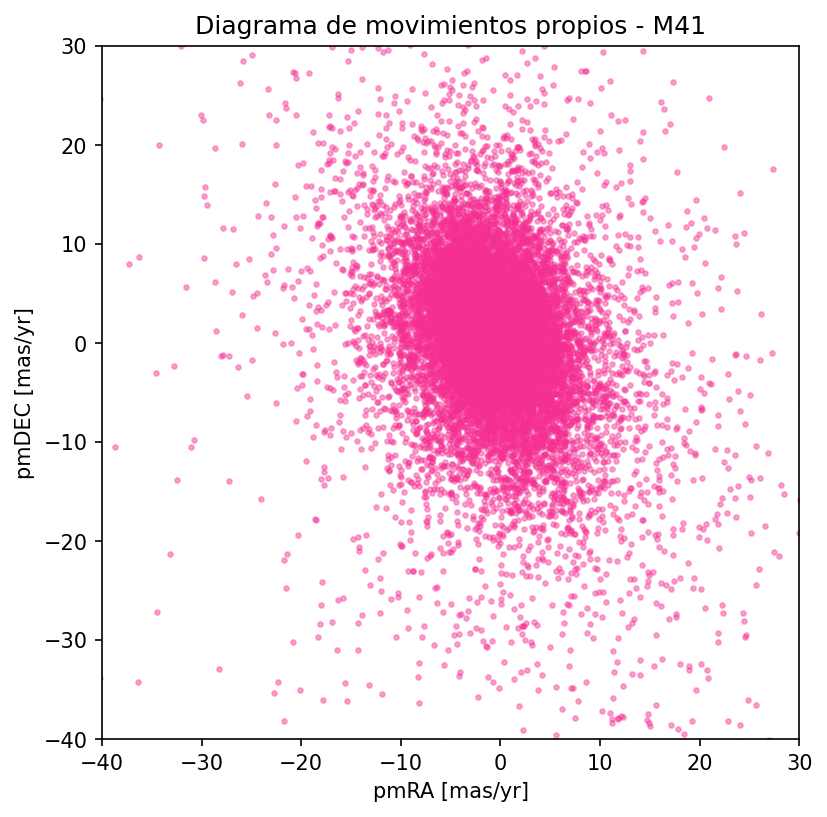

In [53]:
plt.figure(figsize=(6,6), dpi=150)
plt.scatter(mu_x, mu_y, s=5, alpha=0.4, color="#F53093")
plt.xlabel("pmRA [mas/yr]")
plt.xlim(-40,30)
plt.ylabel("pmDEC [mas/yr]")
plt.ylim(-40,30)
plt.title("Diagrama de movimientos propios - M41")
save_current_fig("fig_20_00_97e5ac75.png")
plt.show()


Saved: figuras\fig_21_00_ab2ea21b.png


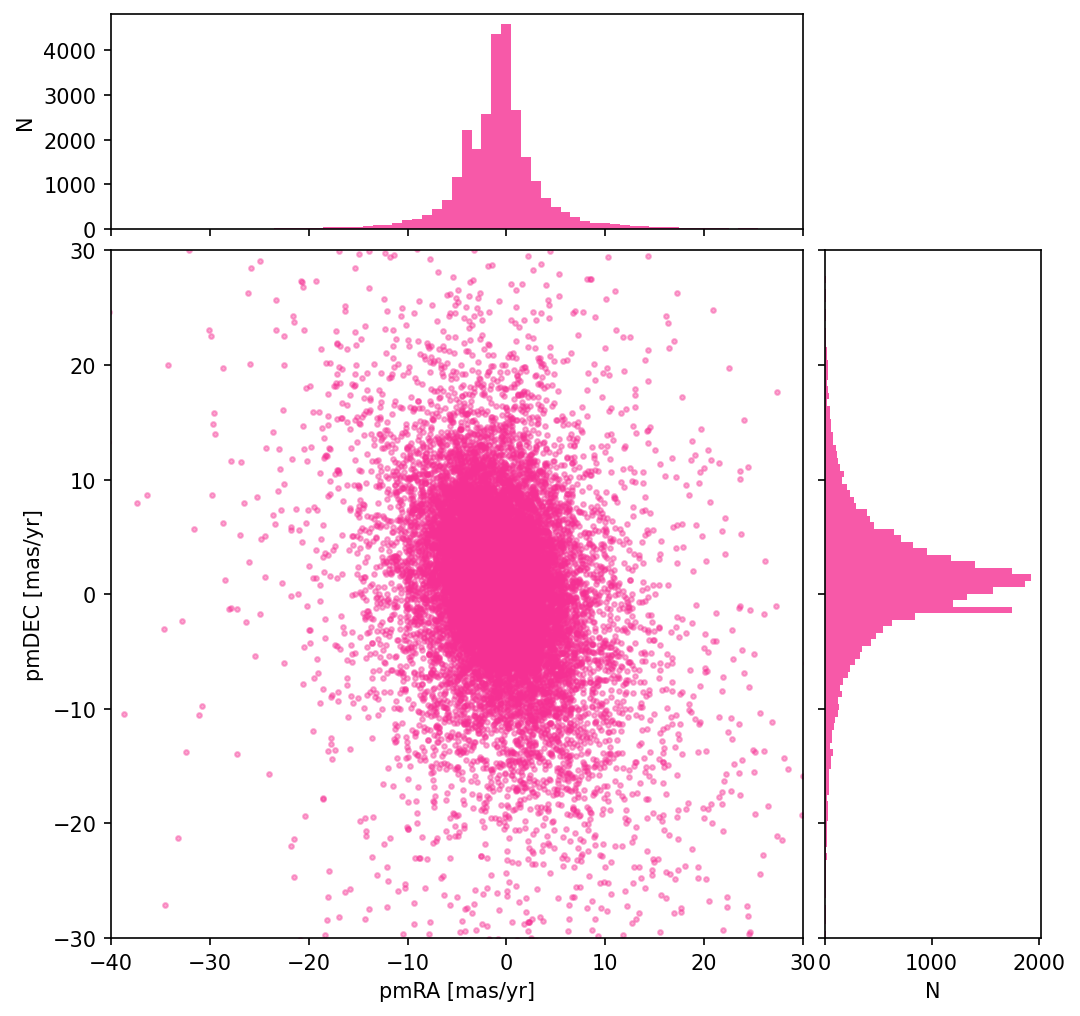

In [54]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(8,8), dpi=150)
gs = GridSpec(4, 4, figure=fig, hspace=0.1, wspace=0.1)

ax_scatter = fig.add_subplot(gs[1:4, 0:3])
ax_histx   = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
ax_histy   = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)

# scatter principal
ax_scatter.scatter(mu_x, mu_y, s=5, alpha=0.4, color="#F53093")
ax_scatter.set_xlabel("pmRA [mas/yr]")
ax_scatter.set_ylabel("pmDEC [mas/yr]")
ax_scatter.set_xlim(-40, 30)
ax_scatter.set_ylim(-30, 30)

# histograma superior (pmRA)
ax_histx.hist(mu_x, bins=500, color="#F53093", alpha=0.8)
ax_histx.set_ylabel("N")
ax_histx.tick_params(axis="x", labelbottom=False)

# histograma derecho (pmDEC)
ax_histy.hist(mu_y, bins=600, orientation="horizontal", color="#F53093", alpha=0.8)
ax_histy.set_xlabel("N")
ax_histy.tick_params(axis="y", labelleft=False)
fig.tight_layout()
save_current_fig("fig_21_00_ab2ea21b.png")
plt.show()


In [19]:


# =========================================================
# 2) VALORES INICIALES
# La tesis usa nf=0.5 y obtiene iniciales desde histogramas.
# Aquí hacemos una aproximación robusta para arrancar el LM.
# =========================================================
# pico del histograma como centro inicial del cúmulo
hist_x, edges_x = np.histogram(mu_x, bins=60)
hist_y, edges_y = np.histogram(mu_y, bins=60)
cx = 0.5 * (edges_x[:-1] + edges_x[1:])
cy = 0.5 * (edges_y[:-1] + edges_y[1:])

# =========================================================
# Picos principales.
# =========================================================

mu_xc0 = df.loc[df['label_hb'] == 1, 'pmra'].median()
mu_yc0 = df.loc[df['label_hb'] == 1, 'pmdec'].median()

print("Pico mu_x =", mu_xc0)
print("Pico mu_y =", mu_yc0)

# radio inicial para separar una zona probable del cúmulo
r0 = 2.5
mask_c0 = ((mu_x - mu_xc0)**2 + (mu_y - mu_yc0)**2) < r0**2

# si sale muy poco, relajamos
if mask_c0.sum() < 20:
    r0 = 4.0
    mask_c0 = ((mu_x - mu_xc0)**2 + (mu_y - mu_yc0)**2) < r0**2

mask_f0 = ~mask_c0

# =========================================================
# dispersión global
# =========================================================

sigma_mux = np.std(mu_x)
sigma_muy = np.std(mu_y)

print("sigma(mu_x) =", sigma_mux)
print("sigma(mu_y) =", sigma_muy)

# parámetros iniciales
sigma0 = np.sqrt((np.var(mu_x[mask_c0]) + np.var(mu_y[mask_c0])) / 2)
sigma0 = max(sigma0, 0.2)

sigma_x0 = max(np.std(mu_x[mask_f0]), 0.5)
sigma_y0 = max(np.std(mu_y[mask_f0]), 0.5)

mu_xf0 = np.mean(mu_x[mask_f0])
mu_yf0 = np.mean(mu_y[mask_f0])

rho0 = np.corrcoef(mu_x[mask_f0], mu_y[mask_f0])[0, 1]
if not np.isfinite(rho0):
    rho0 = 0.0
rho0 = np.clip(rho0, -0.8, 0.8)

nf0 = np.clip(mask_f0.mean(), 0.1, 0.9)

theta0 = np.array([
    mu_xf0, mu_yf0, sigma_x0, sigma_y0,
    mu_xc0, mu_yc0, sigma0, nf0, rho0
], dtype=float)

print("Valores iniciales:")
print(f"mu_xf0={mu_xf0:.4f}, mu_yf0={mu_yf0:.4f}")
print(f"sigma_x0={sigma_x0:.4f}, sigma_y0={sigma_y0:.4f}")
print(f"mu_xc0={mu_xc0:.4f}, mu_yc0={mu_yc0:.4f}")
print(f"sigma0={sigma0:.4f}, nf0={nf0:.4f}, rho0={rho0:.4f}")

Pico mu_x = -4.3632015322756
Pico mu_y = -1.348933378777181
sigma(mu_x) = 6.065595667323696
sigma(mu_y) = 8.24285240773663
Valores iniciales:
mu_xf0=-0.4587, mu_yf0=0.8661
sigma_x0=6.2636, sigma_y0=8.6193
mu_xc0=-4.3632, mu_yc0=-1.3489
sigma0=0.8949, nf0=0.9000, rho0=-0.2806


In [20]:

# =========================================================
# 3) ECUACIONES DEL MODELO
# Basadas en la tesis: cluster circular + campo elíptico
# =========================================================
def psi_cluster(mx, my, mu_xc, mu_yc, sigma):
    return (1.0 / (2.0 * np.pi * sigma**2)) * np.exp(
        -0.5 * (((mx - mu_xc) / sigma)**2 + ((my - mu_yc) / sigma)**2)
    )

def psi_field(mx, my, mu_xf, mu_yf, sigma_x, sigma_y, rho):
    rho   = np.clip(rho, -0.9999, 0.9999)
    denom = 1.0 - rho**2
    Omega = (
        ((mx - mu_xf) / sigma_x)**2
        + ((my - mu_yf) / sigma_y)**2
        - 2.0 * rho * ((mx - mu_xf) / sigma_x) * ((my - mu_yf) / sigma_y)
    )
    return (1.0 / (2.0 * np.pi * sigma_x * sigma_y * np.sqrt(denom))) \
           * np.exp(-Omega / (2.0 * denom))



In [21]:
# =========================================================
# PASO 3 — Ecuaciones score (residuales del sistema MLE)
# Ec. 3-16 a 3-24 de la tesis
# =========================================================
def residuals_mle(theta, mx, my):
    """
    9 ecuaciones score del modelo de mezcla (cúmulo + campo).
    Orden: [mu_xf, mu_yf, sigma_x, sigma_y, mu_xc, mu_yc, sigma, nf, rho]
    """
    mu_xf, mu_yf, sigma_x, sigma_y, mu_xc, mu_yc, sigma, nf, rho = theta

    # restricciones suaves (LM no maneja bounds; se hace así)
    sigma_x = max(sigma_x, 1e-6)
    sigma_y = max(sigma_y, 1e-6)
    sigma   = max(sigma,   1e-6)
    nf  = np.clip(nf,  1e-6, 1 - 1e-6)
    rho = np.clip(rho, -0.999, 0.999)
    nc  = 1.0 - nf

    dx = mx - mu_xf
    dy = my - mu_yf
    Ci = (dx / sigma_x)**2 + (dy / sigma_y)**2
    Ai = np.exp(-Ci / (2.0 * (1.0 - rho**2))) * np.exp(
        rho * dx * dy / (sigma_x * sigma_y * (1.0 - rho**2))
    )
    Bi = np.exp(-0.5 * ((mx - mu_xc)**2 / sigma**2 + (my - mu_yc)**2 / sigma**2))

    psi_i   = nc * (Bi / (2.0 * np.pi * sigma**2)) \
              + nf * (Ai / (2.0 * np.pi * sigma_x * sigma_y * np.sqrt(1.0 - rho**2)))
    psi_inv = 1.0 / np.maximum(psi_i, 1e-300)

    r1 = np.sum(
        (nf / (2.0 * np.pi * sigma_x * sigma_y * np.sqrt(1.0 - rho**2)))
        * psi_inv * Ai
        * (dx / (sigma_x**2 * (1.0 - rho**2))
           - rho * dy / (sigma_x * sigma_y * (1.0 - rho**2)))
    )

    r2 = np.sum(
        (nf / (2.0 * np.pi * sigma_x * sigma_y * np.sqrt(1.0 - rho**2)))
        * psi_inv * Ai
        * (dy / (sigma_y**2 * (1.0 - rho**2))
           - rho * dx / (sigma_x * sigma_y * (1.0 - rho**2)))
    )

    r3 = np.sum(
        (nf / (2.0 * np.pi * sigma_x**2 * sigma_y * (1.0 - rho**2)**1.5))
        * psi_inv * Ai
        * ((dx / sigma_x)**2
           - rho * dx * dy / (sigma_x * sigma_y)
           - (1.0 - rho**2))          # ← CORRECTO
    )

    r4 = np.sum(
        (nf / (2.0 * np.pi * sigma_y**2 * sigma_x * (1.0 - rho**2)**1.5))
        * psi_inv * Ai
        * ((dy / sigma_y)**2
           - rho * dx * dy / (sigma_x * sigma_y)
           - (1.0 - rho**2))          # ← CORRECTO
    )

    r5 = np.sum(
        (nc / (2.0 * np.pi * sigma**4))
        * psi_inv * Bi * (mx - mu_xc)
    )

    r6 = np.sum(
        (nc / (2.0 * np.pi * sigma**4))
        * psi_inv * Bi * (my - mu_yc)
    )

    r7 = np.sum(
        (nc / (2.0 * np.pi * sigma**3))
        * psi_inv * Bi
        * (((mx - mu_xc) / sigma)**2 + ((my - mu_yc) / sigma)**2 - 2.0)
    )

    r8 = np.sum(
        psi_inv * (
            Ai / (2.0 * np.pi * sigma_x * sigma_y * np.sqrt(1.0 - rho**2))
            - Bi / (2.0 * np.pi * sigma**2)
        )
    )

    r9 = np.sum(
        (nf / (2.0 * np.pi * sigma_x * sigma_y * (1.0 - rho**2)**1.5))
        * psi_inv * Ai
        * (rho
           + (1.0 + rho**2) * dx * dy / (sigma_x * sigma_y * (1.0 - rho**2))
           - rho * Ci / (1.0 - rho**2))
    )

    return np.array([r1, r2, r3, r4, r5, r6, r7, r8, r9], dtype=float)

In [22]:


# =========================================================
# 4) AJUSTE CON LEVENBERG–MARQUARDT
# =========================================================
from scipy.optimize import root

eps = 1e-4
r0  = residuals_mle(theta0, mu_x, mu_y)
scale = np.ones(9)
for j in range(9):
    t_plus = theta0.copy()
    t_plus[j] += eps
    scale[j] = max(abs((residuals_mle(t_plus, mu_x, mu_y)[j] - r0[j]) / eps), 1.0)

def residuals_normalized(theta, mx, my):
    return residuals_mle(theta, mx, my) / scale   # cada r_i queda O(1)

res = root(
    residuals_normalized,
    theta0,
    args=(mu_x, mu_y),
    method='hybr',
    options={'maxfev': 50000, 'xtol': 1e-10}
)

theta_hat = res.x
mu_xf, mu_yf, sigma_x, sigma_y, mu_xc, mu_yc, sigma, nf, rho = theta_hat
nf = np.clip(nf, 1e-6, 1-1e-6)
nc = 1.0 - nf
rho = np.clip(rho, -0.999, 0.999)


print("\nParámetros finales (MLE + LM):")
print(f"mu_xf = {mu_xf:.6f}")
print(f"mu_yf = {mu_yf:.6f}")
print(f"sigma_x = {sigma_x:.6f}")
print(f"sigma_y = {sigma_y:.6f}")
print(f"mu_xc = {mu_xc:.6f}")
print(f"mu_yc = {mu_yc:.6f}")
print(f"sigma = {sigma:.6f}")
print(f"nf = {nf:.6f}")
print(f"nc = {nc:.6f}")
print(f"rho = {rho:.6f}")
print(f"Convergió: {res.success}, mensaje: {res.message}")



Parámetros finales (MLE + LM):
mu_xf = -0.554327
mu_yf = 0.800564
sigma_x = 5.693063
sigma_y = 8.459517
mu_xc = -3.732720
mu_yc = -1.044188
sigma = 1.016384
nf = 0.929584
nc = 0.070416
rho = -0.287829
Convergió: True, mensaje: The solution converged.


In [23]:
# =========================================================
# 5) PROBABILIDAD DE PERTENENCIA
# =========================================================
psi_c = psi_cluster(mu_x, mu_y, mu_xc, mu_yc, sigma)
psi_f = psi_field(mu_x, mu_y, mu_xf, mu_yf, sigma_x, sigma_y, rho)

P = (nc * psi_c) / np.maximum(nf * psi_f + nc * psi_c, 1e-300)

df["P_member"] = P
df["is_member"] = df["P_member"] >= 0.5

Saved: figuras\fig_27_00_68f08be3.png


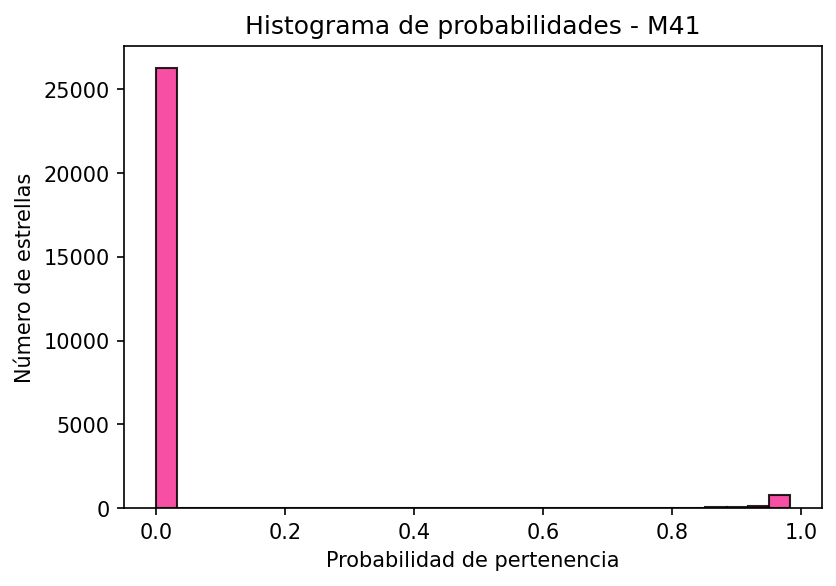

In [55]:
# =========================================================
# 6) HISTOGRAMA DE PROBABILIDADES
# =========================================================
plt.figure(figsize=(6,4), dpi=150)
plt.hist(df["P_member"], bins=30, color="#F53093", edgecolor="black", alpha=0.85)
plt.xlabel("Probabilidad de pertenencia")
plt.ylabel("Número de estrellas")
plt.title("Histograma de probabilidades - M41")
save_current_fig("fig_27_00_68f08be3.png")
plt.show()


Saved: figuras\fig_28_00_260c3c09.png


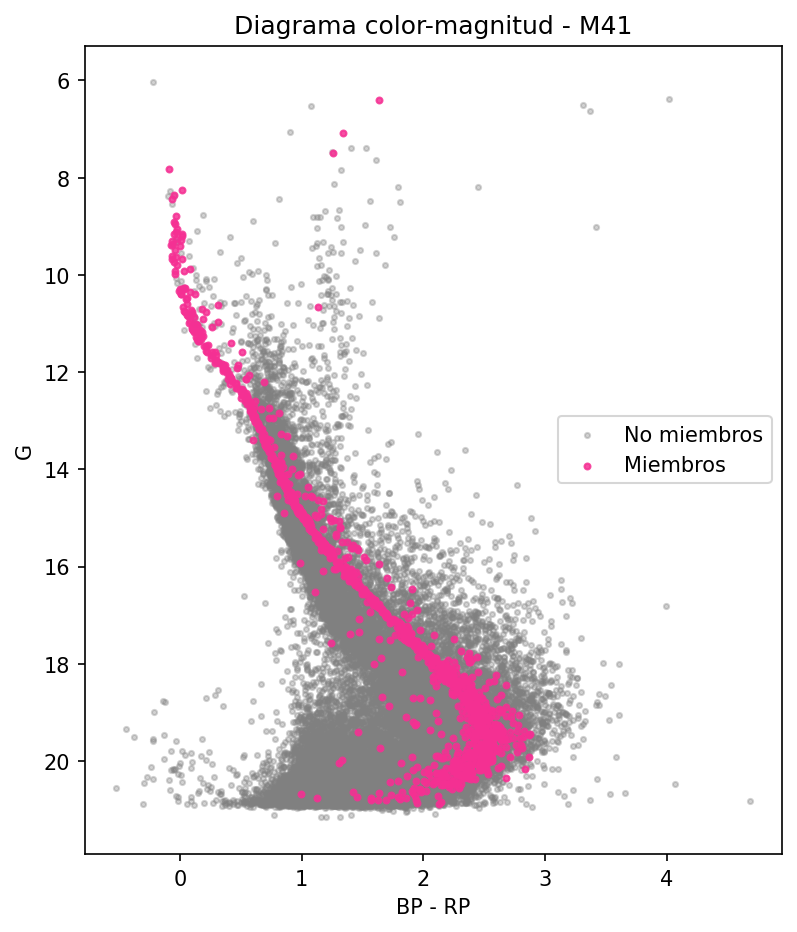

In [56]:
# =========================================================
# 7) CMD
# =========================================================
plt.figure(figsize=(6,7), dpi=150)

plt.scatter(
    df.loc[~df["is_member"], "bp_rp"],
    df.loc[~df["is_member"], "phot_g_mean_mag"],
    s=6, c="gray", alpha=0.35, label="No miembros"
)

plt.scatter(
    df.loc[df["is_member"], "bp_rp"],
    df.loc[df["is_member"], "phot_g_mean_mag"],
    s=8, c="#F53093", alpha=0.85, label="Miembros"
)

plt.gca().invert_yaxis()
plt.xlabel("BP - RP")
plt.ylabel("G")
plt.title("Diagrama color-magnitud - M41")
plt.legend()
save_current_fig("fig_28_00_260c3c09.png")
plt.show()



Saved: figuras\fig_29_00_565495fd.png


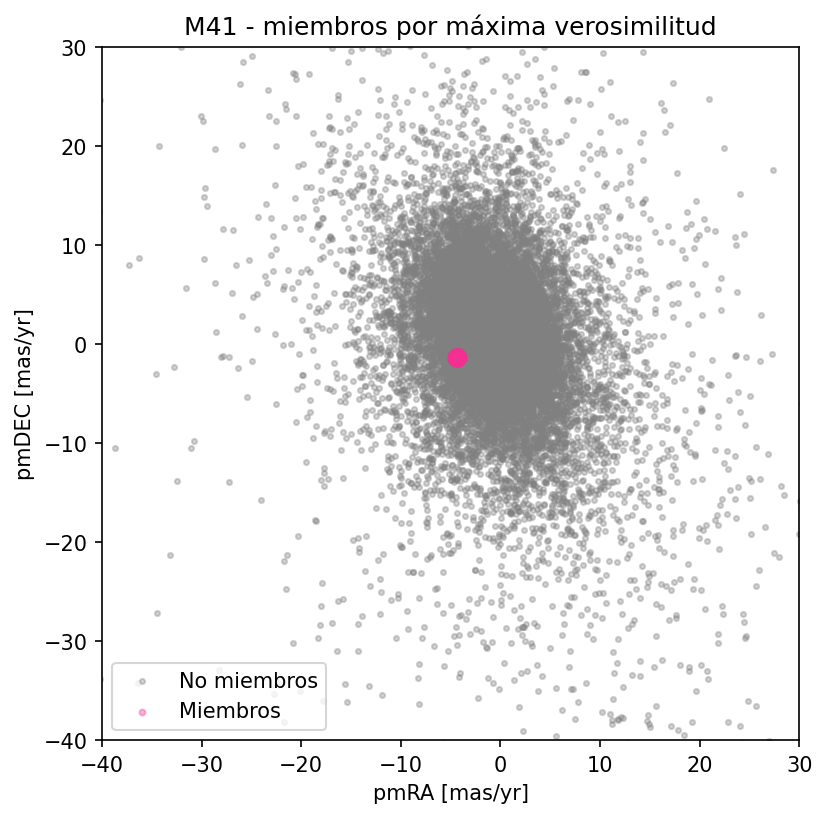

In [57]:
# =========================================================
# 8) DVP COLOREADO
# =========================================================
plt.figure(figsize=(6,6), dpi=150)
plt.scatter(
    df.loc[~df["is_member"], "pmra"],
    df.loc[~df["is_member"], "pmdec"],
    s=6, c="gray", alpha=0.35, label="No miembros"
)
plt.scatter(
    df.loc[df["is_member"], "pmra"],
    df.loc[df["is_member"], "pmdec"],
    s=8, color="#F53093", alpha=0.35, label="Miembros"
)
plt.xlabel("pmRA [mas/yr]")
plt.xlim(-40,30)
plt.ylabel("pmDEC [mas/yr]")
plt.ylim(-40,30)
plt.title("M41 - miembros por máxima verosimilitud")
plt.legend()
save_current_fig("fig_29_00_565495fd.png")
plt.show()


In [27]:
# =========================================================
# 9) RESUMEN
# =========================================================
print("\nResumen:")
print(f"Total estrellas: {len(df)}")
print(f"Miembros (P >= 0.5): {df['is_member'].sum()}")
print(f"No miembros: {(~df['is_member']).sum()}")


Resumen:
Total estrellas: 27590
Miembros (P >= 0.5): 2011
No miembros: 25579


# ALTERNATIVA: LOG LIKELIHOOD Y MINIMIZE (EQUIVALENTE PERO DA MEJOR)

In [28]:

from scipy.optimize import minimize

# -------------------------------------------------------
# Funciones de densidad 
# -------------------------------------------------------
def psi_cluster(mx, my, mu_xc, mu_yc, sigma):
    sigma = max(sigma, 1e-8)
    return (1.0 / (2.0 * np.pi * sigma**2)) * np.exp(
        -0.5 * (((mx - mu_xc)/sigma)**2 + ((my - mu_yc)/sigma)**2)
    )

def psi_field(mx, my, mu_xf, mu_yf, sigma_x, sigma_y, rho):
    sigma_x = max(sigma_x, 1e-8)
    sigma_y = max(sigma_y, 1e-8)
    rho = np.clip(rho, -0.999, 0.999)
    Omega = (
        ((mx - mu_xf)/sigma_x)**2
        + ((my - mu_yf)/sigma_y)**2
        - 2.0 * rho * ((mx - mu_xf)/sigma_x) * ((my - mu_yf)/sigma_y)
    )
    norm = 1.0 / (2.0 * np.pi * sigma_x * sigma_y * np.sqrt(1.0 - rho**2))
    return norm * np.exp(-Omega / (2.0 * (1.0 - rho**2)))


# -------------------------------------------------------
#  log-likelihood directo
# -------------------------------------------------------
def neg_log_likelihood(theta, mx, my):
    mu_xf, mu_yf, sigma_x, sigma_y, mu_xc, mu_yc, sigma, nf, rho = theta
    nc = 1.0 - nf

    psi_c = psi_cluster(mx, my, mu_xc, mu_yc, sigma)
    psi_f = psi_field(mx, my, mu_xf, mu_yf, sigma_x, sigma_y, rho)

    psi_i = nc * psi_c + nf * psi_f
    psi_i = np.maximum(psi_i, 1e-300)  # evitar log(0)

    return -np.sum(np.log(psi_i))



cluster_mask = df['label_hb'] == 1          # etiqueta del cúmulo en HDBSCAN
mu_xc0 = df.loc[cluster_mask, 'pmra'].median()
mu_yc0 = df.loc[cluster_mask, 'pmdec'].median()
sigma0  = df.loc[cluster_mask, 'pmra'].std()  # dispersión interna del cúmulo
sigma0  = max(sigma0, 0.2)

# Estimación del campo 
field_mask = ~cluster_mask
mu_xf0 = df.loc[field_mask, 'pmra'].median()
mu_yf0 = df.loc[field_mask, 'pmdec'].median()
sigma_x0 = max(df.loc[field_mask, 'pmra'].std(), 0.5)
sigma_y0 = max(df.loc[field_mask, 'pmdec'].std(), 0.5)
rho0 = np.corrcoef(df.loc[field_mask, 'pmra'], df.loc[field_mask, 'pmdec'])[0, 1]
rho0 = np.clip(rho0 if np.isfinite(rho0) else 0.0, -0.8, 0.8)

nf0 = np.clip(field_mask.mean(), 0.1, 0.95)

theta0 = np.array([
    mu_xf0, mu_yf0, sigma_x0, sigma_y0,
    mu_xc0, mu_yc0, sigma0, nf0, rho0
], dtype=float)

print("Valores iniciales corregidos:")
print(f"  mu_xc0={mu_xc0:.3f}, mu_yc0={mu_yc0:.3f}")
print(f"  sigma0={sigma0:.3f}")
print(f"  mu_xf0={mu_xf0:.3f}, mu_yf0={mu_yf0:.3f}")
print(f"  sigma_x0={sigma_x0:.3f}, sigma_y0={sigma_y0:.3f}")
print(f"  nf0={nf0:.4f}, rho0={rho0:.4f}")


# -------------------------------------------------------
# FIX 3: Optimización directa con bounds (L-BFGS-B)
# -------------------------------------------------------
bounds = [
    (-30, 20),      # mu_xf
    (-30, 20),      # mu_yf
    (0.1, 40),      # sigma_x  (campo puede ser muy ancho)
    (0.1, 40),      # sigma_y
    (-15, 5),       # mu_xc
    (-20, 5),       # mu_yc
    (0.01, 5),      # sigma  (dispersión interna del cúmulo)
    (0.01, 0.99),   # nf
    (-0.99, 0.99),  # rho
]

res = minimize(
    neg_log_likelihood,
    theta0,
    args=(mu_x, mu_y),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 20000, 'ftol': 1e-14, 'gtol': 1e-8}
)

theta_hat = res.x
mu_xf, mu_yf, sigma_x, sigma_y, mu_xc, mu_yc, sigma, nf, rho = theta_hat
nc = 1.0 - nf

print(f"\nParámetros finales (MLE directo):")
print(f"  mu_xf={mu_xf:.4f}, mu_yf={mu_yf:.4f}")
print(f"  sigma_x={sigma_x:.4f}, sigma_y={sigma_y:.4f}, rho={rho:.4f}")
print(f"  mu_xc={mu_xc:.4f}, mu_yc={mu_yc:.4f}, sigma={sigma:.4f}")
print(f"  nf={nf:.6f}, nc={nc:.6f}")
print(f"  Convergió: {res.success} — {res.message}")


# -------------------------------------------------------
# -------------------------------------------------------
psi_c = psi_cluster(mu_x, mu_y, mu_xc, mu_yc, sigma)
psi_f = psi_field(mu_x, mu_y, mu_xf, mu_yf, sigma_x, sigma_y, rho)

P = (nc * psi_c) / np.maximum(nf * psi_f + nc * psi_c, 1e-300)

df["P_member"] = P
df["is_member"] = df["P_member"] >= 0.5

print(f"\nMiembros (P >= 0.5): {df['is_member'].sum()}")
print(f"No miembros:         {(~df['is_member']).sum()}")

Valores iniciales corregidos:
  mu_xc0=-4.363, mu_yc0=-1.349
  sigma0=0.239
  mu_xf0=-0.596, mu_yf0=1.212
  sigma_x0=6.145, sigma_y0=8.402
  nf0=0.9500, rho0=-0.2712

Parámetros finales (MLE directo):
  mu_xf=-0.6346, mu_yf=0.7619
  sigma_x=5.7493, sigma_y=8.3991, rho=-0.3022
  mu_xc=-4.3690, mu_yc=-1.3452, sigma=0.2161
  nf=0.959673, nc=0.040327
  Convergió: True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Miembros (P >= 0.5): 1166
No miembros:         26424


Saved: figuras\fig_33_00_edfe4a0b.png


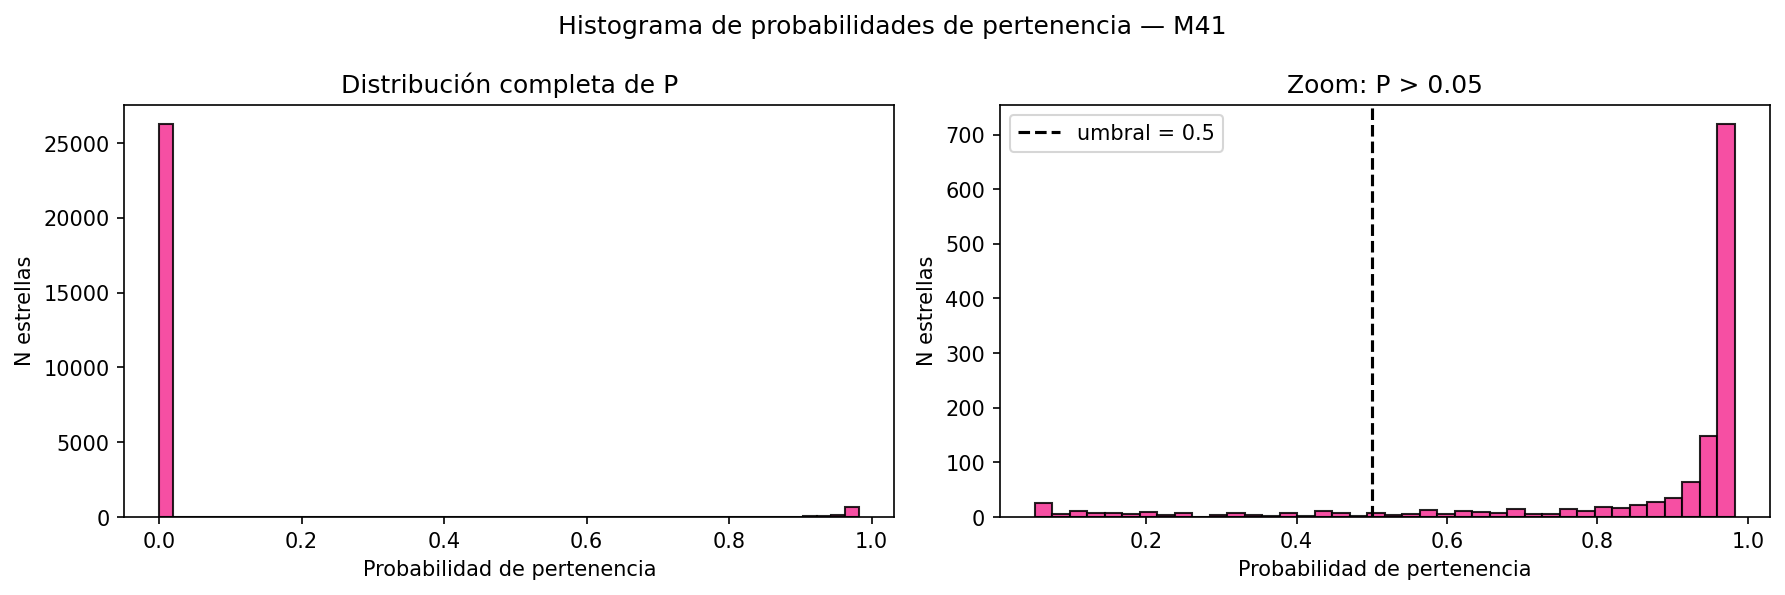

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

# Histograma completo
axes[0].hist(df['P_member'], bins=50, color='#F53093', edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Probabilidad de pertenencia')
axes[0].set_ylabel('N estrellas')
axes[0].set_title('Distribución completa de P')

# Zoom en P > 0.05 (para ver la cola del cúmulo)
axes[1].hist(df.loc[df['P_member'] > 0.05, 'P_member'],
             bins=40, color='#F53093', edgecolor='black', alpha=0.85)
axes[1].axvline(0.5, color='black', linestyle='--', label='umbral = 0.5')
axes[1].set_xlabel('Probabilidad de pertenencia')
axes[1].set_ylabel('N estrellas')
axes[1].set_title('Zoom: P > 0.05')
axes[1].legend()

fig.suptitle('Histograma de probabilidades de pertenencia — M41')
plt.tight_layout()
save_current_fig("fig_33_00_edfe4a0b.png")
plt.show()


Saved: figuras\fig_34_00_3d9dbf94.png


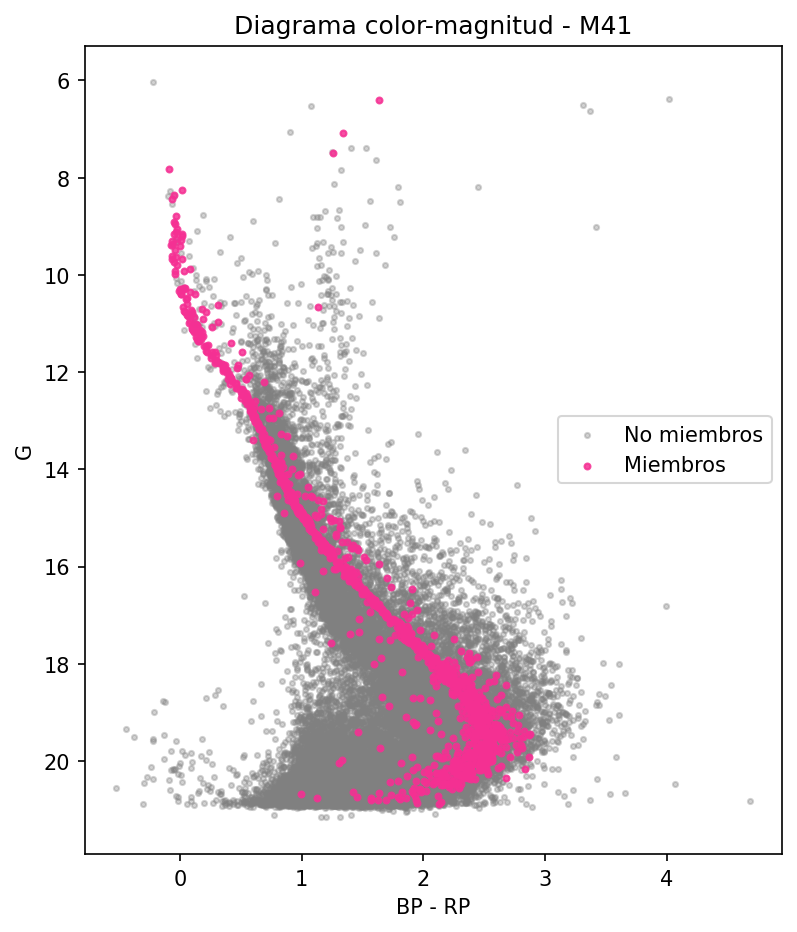

In [59]:
# =========================================================
# 7) CMD
# =========================================================
plt.figure(figsize=(6,7), dpi=150)

plt.scatter(
    df.loc[~df["is_member"], "bp_rp"],
    df.loc[~df["is_member"], "phot_g_mean_mag"],
    s=6, c="gray", alpha=0.35, label="No miembros"
)

plt.scatter(
    df.loc[df["is_member"], "bp_rp"],
    df.loc[df["is_member"], "phot_g_mean_mag"],
    s=8, c="#F53093", alpha=0.85, label="Miembros"
)

plt.gca().invert_yaxis()
plt.xlabel("BP - RP")
plt.ylabel("G")
plt.title("Diagrama color-magnitud - M41")
plt.legend()
save_current_fig("fig_34_00_3d9dbf94.png")
plt.show()



Saved: figuras\fig_35_00_f952c3cd.png


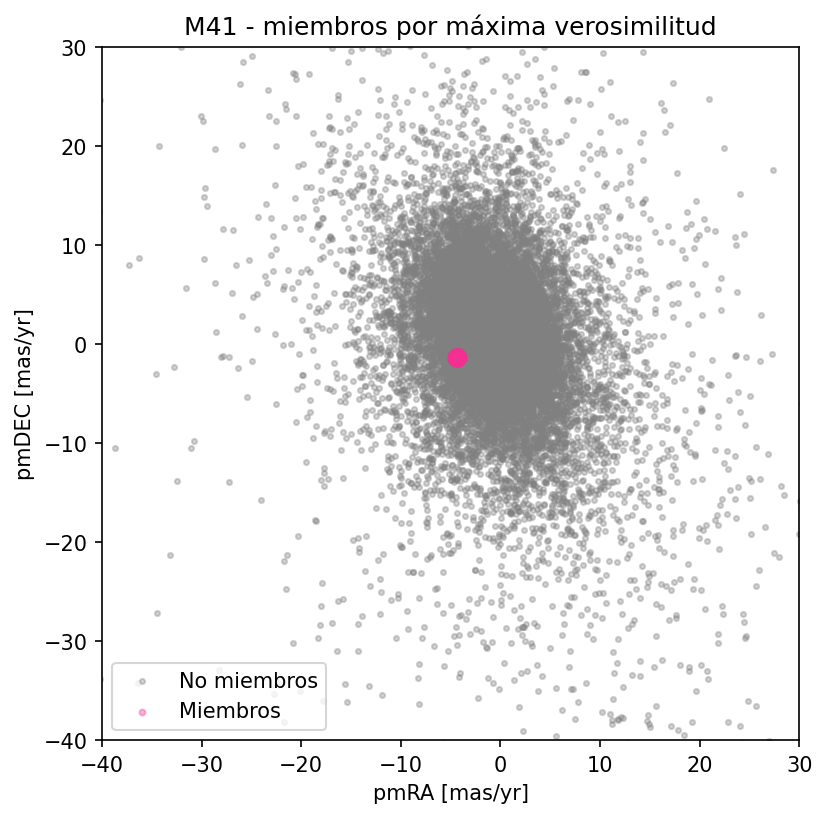

In [60]:
# =========================================================
# 8) DVP COLOREADO
# =========================================================
plt.figure(figsize=(6,6), dpi=150)
plt.scatter(
    df.loc[~df["is_member"], "pmra"],
    df.loc[~df["is_member"], "pmdec"],
    s=6, c="gray", alpha=0.35, label="No miembros"
)
plt.scatter(
    df.loc[df["is_member"], "pmra"],
    df.loc[df["is_member"], "pmdec"],
    s=8, color="#F53093", alpha=0.35, label="Miembros"
)
plt.xlabel("pmRA [mas/yr]")
plt.xlim(-40,30)
plt.ylabel("pmDEC [mas/yr]")
plt.ylim(-40,30)
plt.title("M41 - miembros por máxima verosimilitud")
plt.legend()
save_current_fig("fig_35_00_f952c3cd.png")
plt.show()


Saved: figuras\fig_36_00_51a91711.png


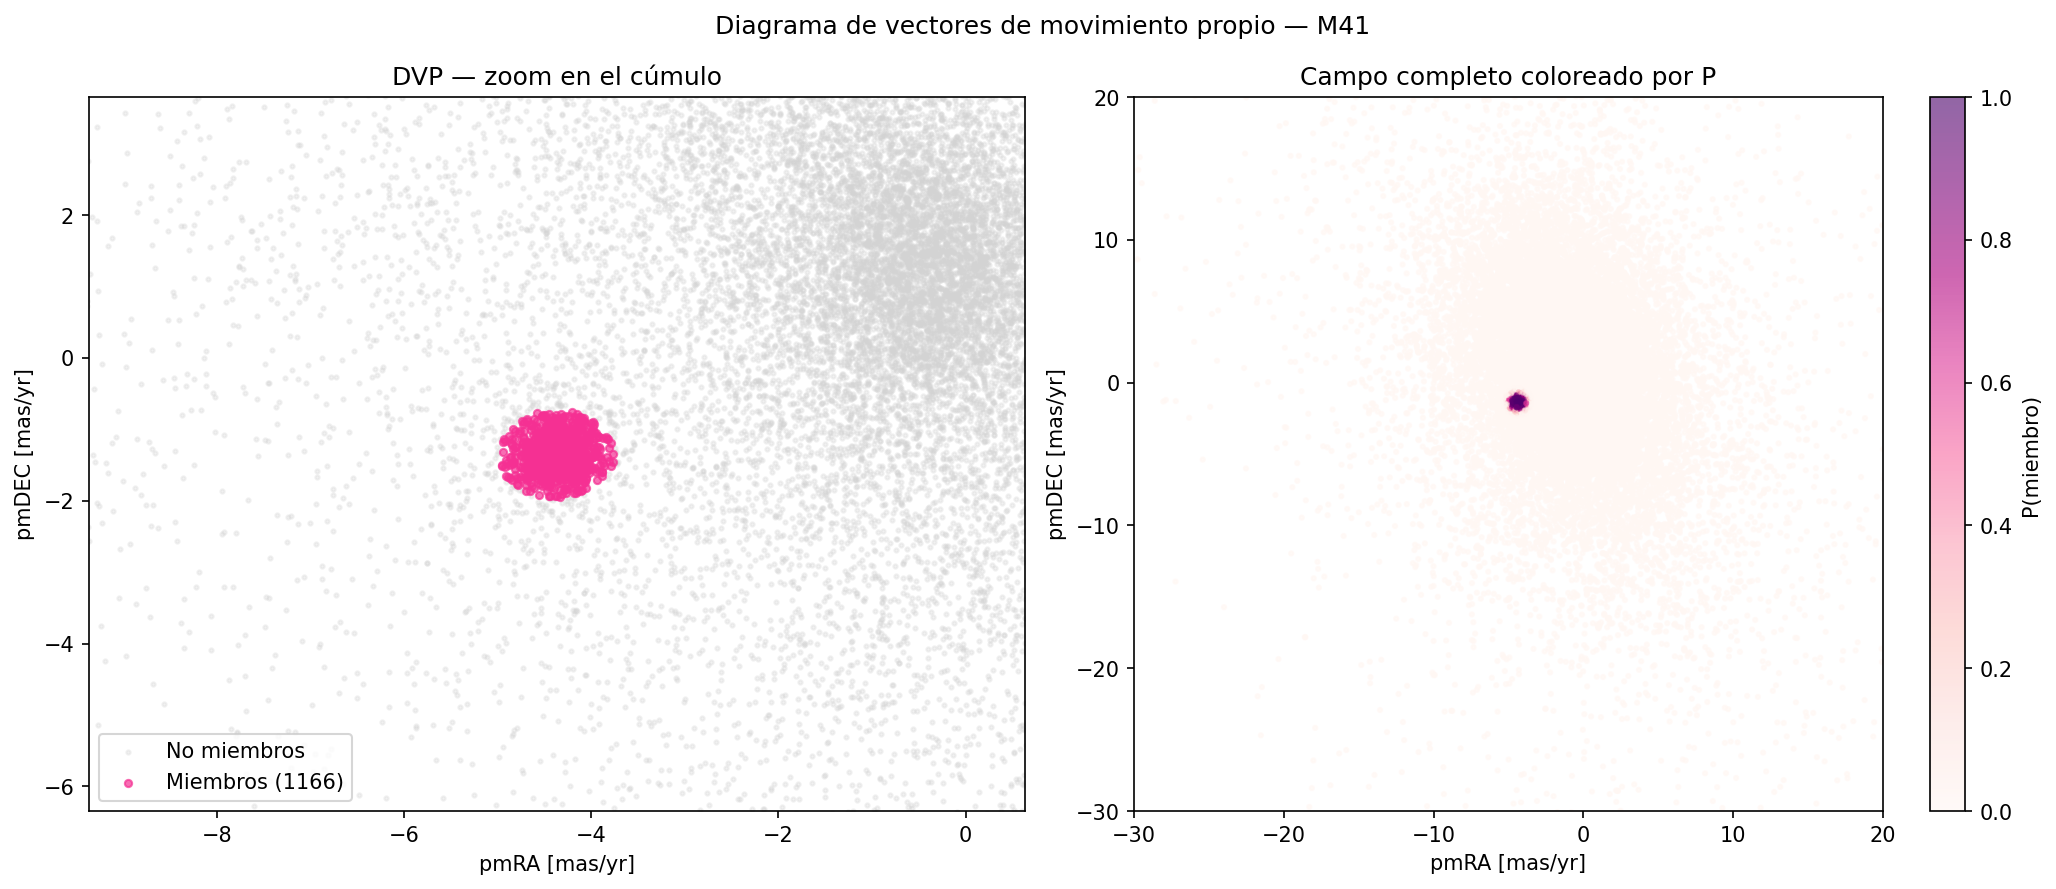

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# Izquierda: miembros vs no miembros
ax = axes[0]
ax.scatter(df.loc[~df['is_member'], 'pmra'], df.loc[~df['is_member'], 'pmdec'],
           s=4, c='lightgray', alpha=0.3, label='No miembros')
ax.scatter(df.loc[df['is_member'], 'pmra'], df.loc[df['is_member'], 'pmdec'],
           s=12, color='#F53093', alpha=0.7, label=f'Miembros ({df["is_member"].sum()})')
ax.set_xlabel('pmRA [mas/yr]')
ax.set_ylabel('pmDEC [mas/yr]')
ax.set_xlim(mu_xc - 5, mu_xc + 5)
ax.set_ylim(mu_yc - 5, mu_yc + 5)
ax.set_title('DVP — zoom en el cúmulo')
ax.legend()

# Derecha: continuo de probabilidad
ax2 = axes[1]
sc = ax2.scatter(df['pmra'], df['pmdec'],
                 c=df['P_member'], cmap='RdPu', s=4, alpha=0.6,
                 vmin=0, vmax=1)
plt.colorbar(sc, ax=ax2, label='P(miembro)')
ax2.set_xlabel('pmRA [mas/yr]')
ax2.set_ylabel('pmDEC [mas/yr]')
ax2.set_xlim(-30, 20)
ax2.set_ylim(-30, 20)
ax2.set_title('Campo completo coloreado por P')

fig.suptitle('Diagrama de vectores de movimiento propio — M41')
plt.tight_layout()
save_current_fig("fig_36_00_51a91711.png")
plt.show()


Saved: figuras\fig_38_00_65a475fd.png


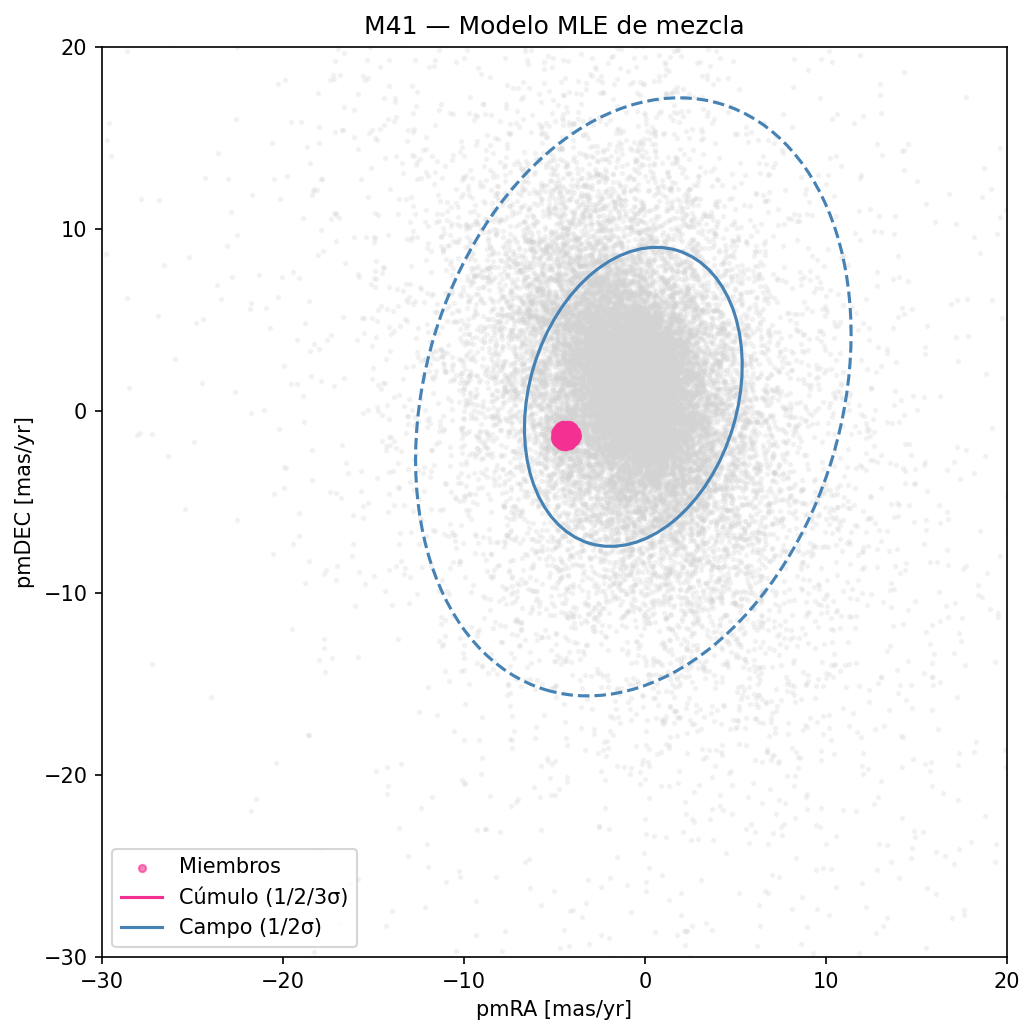


Resumen final:
  mu_xc = -4.3690 ± 0.2161 mas/yr
  mu_yc = -1.3452 ± 0.2161 mas/yr
  Fracción campo nc = 0.0403  (4.0%)
  Fracción campo nf = 0.9597  (96.0%)
  Miembros con P >= 0.5: 1166


In [62]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(7, 7), dpi=150)

# Todos los puntos con transparencia
ax.scatter(mu_x, mu_y, s=3, c='lightgray', alpha=0.2)

# Miembros destacados
ax.scatter(df.loc[df['is_member'], 'pmra'], df.loc[df['is_member'], 'pmdec'],
           s=12, color='#F53093', alpha=0.6, label='Miembros', zorder=3)

# Elipse del cúmulo (1σ y 2σ)
for n_sigma in [1, 2, 3]:
    ell_c = Ellipse(
        (mu_xc, mu_yc), width=2*n_sigma*sigma, height=2*n_sigma*sigma,
        edgecolor='#F53093', facecolor='none', linewidth=1.5,
        linestyle='-' if n_sigma == 1 else '--'
    )
    ax.add_patch(ell_c)
ax.plot([], [], color='#F53093', linestyle='-',  label='Cúmulo (1/2/3σ)')

# Elipse del campo
angle_field = 0.0  # rho codifica la correlación, no una rotación pura
for n_sigma in [1, 2]:
    ell_f = Ellipse(
        (mu_xf, mu_yf), width=2*n_sigma*sigma_x, height=2*n_sigma*sigma_y,
        angle=np.degrees(np.arctan2(rho, 1)) if abs(rho) > 0.05 else 0,
        edgecolor='steelblue', facecolor='none', linewidth=1.5,
        linestyle='-' if n_sigma == 1 else '--'
    )
    ax.add_patch(ell_f)
ax.plot([], [], color='steelblue', linestyle='-', label='Campo (1/2σ)')

ax.set_xlabel('pmRA [mas/yr]')
ax.set_ylabel('pmDEC [mas/yr]')
ax.set_xlim(-30, 20)
ax.set_ylim(-30, 20)
ax.set_title('M41 — Modelo MLE de mezcla')
ax.legend()
plt.tight_layout()
save_current_fig("fig_38_00_65a475fd.png")
plt.show()


print(f'\nResumen final:')
print(f'  mu_xc = {mu_xc:.4f} ± {sigma:.4f} mas/yr')
print(f'  mu_yc = {mu_yc:.4f} ± {sigma:.4f} mas/yr')
print(f'  Fracción campo nc = {nc:.4f}  ({nc*100:.1f}%)')
print(f'  Fracción campo nf = {nf:.4f}  ({nf*100:.1f}%)')
print(f'  Miembros con P >= 0.5: {df["is_member"].sum()}')